# 트랜스포머을 이용한 저수율 예측

## [0] 라이브러리 설치 및 호출

In [1]:
# 필요한 라이브러리 설치 (주피터 환경에서 실행)
# !pip install pandas numpy scikit-learn matplotlib tsfresh

# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest # 이상치 탐지 모델
from scipy.stats import iqr # 사분위수 범위 계산

## [1] 데이터 로드 및 전처리

### (1) 데이터 로드 

In [8]:
# ----------------------------------------------------
# 0단계: 데이터 로드 및 기본 전처리
# ----------------------------------------------------

df_raw = pd.read_csv('full_dataset_fixed.csv')
# '날짜' 컬럼을 datetime 형식으로 변환
df_raw['날짜'] = pd.to_datetime(df_raw['날짜'])


### (2-1) 데이터 전처리: 10%미만 저수지 제거

In [14]:
# ----------------------------------------------------
# 1단계: 저수지ID 기준으로 10점(%) 미만 저수지 제거
# ----------------------------------------------------

# '저수지명' 대신 '저수지ID'를 기준으로 그룹핑
reservoirs_to_remove = df_raw.groupby('저수지ID')['저수율'].min()
# 기준을 10으로 설정 (0~100 스케일)
reservoirs_to_remove = reservoirs_to_remove[reservoirs_to_remove < 10].index.tolist()

print(f"ID 기준으로 새로 식별된 10% 미만 기록 저수지 수: {len(reservoirs_to_remove)}개")

# 식별된 저수지ID를 데이터에서 제거
df_filtered_new = df_raw[~df_raw['저수지ID'].isin(reservoirs_to_remove)]
print(f"최종 필터링 후 남은 저수지 수: {df_filtered_new['저수지ID'].nunique()}개")

# 다음 단계의 코드를 위해 df_filtered를 업데이트
df_filtered = df_filtered_new.copy()

# ----------------------------------------------------
# 2단계: 패턴 이상치 제거 (저수지ID 기준)
# ----------------------------------------------------

reservoir_features = df_filtered.groupby('저수지ID')['저수율'].agg([
    'mean', 'std', 'min', 'max'
]).reset_index()

# ... 이후 Isolation Forest 및 K-means 진행

ID 기준으로 새로 식별된 10% 미만 기록 저수지 수: 84개
최종 필터링 후 남은 저수지 수: 855개


In [15]:
# 1단계에서 생성된 필터링된 데이터프레임 (df_filtered_new) 사용
output_csv_filename = 'reservoir_Clean_Filtered.csv'

df_filtered_new.to_csv(
    output_csv_filename, 
    index=False,        # 행 인덱스를 파일에 저장하지 않음(필수)
    encoding='utf-8'    # 한글 깨짐 방지를 위해 인코딩을 지정
)

print(f"\n✅ 클린 데이터가 '{output_csv_filename}' 파일로 저장되었습니다.")
print(f"저장된 파일의 총 행 수: {len(df_filtered_new)}")


✅ 클린 데이터가 'reservoir_Clean_Filtered.csv' 파일로 저장되었습니다.
저장된 파일의 총 행 수: 1247694


In [1]:
import pandas as pd
import numpy as np

# 저장된 파일 이름
input_csv_filename = 'reservoir_Clean_Filtered.csv'

# 파일 로드 및 df_filtered 변수 복구
try:
    df_loaded = pd.read_csv(input_csv_filename)
    # '날짜' 컬럼을 datetime 형식으로 변환 (원본 노트북에서 수행한 전처리)
    df_loaded['날짜'] = pd.to_datetime(df_loaded['날짜'])
    
    # 다음 단계를 위해 df_filtered 변수 업데이트
    # Code Cell 14에서 df_filtered = df_filtered_new.copy()를 했으므로, df_filtered를 로드된 데이터로 설정
    df_filtered = df_loaded.copy()
    
    print(f"✅ '{input_csv_filename}' 파일이 성공적으로 로드되어 df_filtered 변수가 복구되었습니다.")
    print(f"복구된 데이터의 총 행 수: {len(df_filtered):,} 행")
    
except FileNotFoundError:
    print(f"❌ ERROR: '{input_csv_filename}' 파일을 찾을 수 없습니다.")
    print("원활한 진행을 위해 Code Cell 7, 8, 14를 순서대로 실행하여 df_filtered를 재생성해 주세요.")
    df_filtered = None

✅ 'reservoir_Clean_Filtered.csv' 파일이 성공적으로 로드되어 df_filtered 변수가 복구되었습니다.
복구된 데이터의 총 행 수: 1,247,694 행


### (2-2) 데이터 전처리: 패턴 이상치 저수지 제거

In [2]:
# ----------------------------------------------------
# 2단계: 패턴 이상치 (Outlier) 저수지 제거
# ----------------------------------------------------
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# 2-1. 저수지별 패턴 특징 추출
# 남은 730개 저수지에 대해 패턴 특징 추출
reservoir_features = df_filtered.groupby('저수지ID')['저수율'].agg([
    'mean', # 평균 저수율
    'std',  # 변동성 (표준편차)
    'min',  # 최소 저수율 (이미 10 이상)
    'max'   # 최대 저수율
]).reset_index()
reservoir_features = reservoir_features.dropna() # 안전을 위해 결측치 제거 (std가 NaN인 경우 등)

# 2-2. 특징 데이터 정규화 (이상치 탐지 전에 스케일 맞추기)
scaler = StandardScaler()
features_for_iso = reservoir_features[['mean', 'std', 'min', 'max']].copy()
features_scaled = scaler.fit_transform(features_for_iso)
df_features_scaled = pd.DataFrame(features_scaled, columns=['mean_s', 'std_s', 'min_s', 'max_s'])

# 2-3. Isolation Forest를 이용한 이상치 탐지
# contamination=0.05 (전체 중 5%를 이상치로 간주)
iso_forest = IsolationForest(contamination=0.05, random_state=42)
reservoir_features['outlier_score'] = iso_forest.fit_predict(df_features_scaled)

# outlier_score가 -1인 경우 이상치(제거 대상)
outlier_reservoirs = reservoir_features[reservoir_features['outlier_score'] == -1]['저수지ID'].tolist()
print(f"\nIsolation Forest로 탐지된 패턴 이상치 저수지 수: {len(outlier_reservoirs)}개")

# 2-4. 이상치 저수지 최종 제거
df_clean = df_filtered[~df_filtered['저수지ID'].isin(outlier_reservoirs)]
print(f"최종 클러스터링 대상 저수지 수: {df_clean['저수지ID'].nunique()}개")

# 클러스터링에 사용할 최종 특징 데이터셋 준비 (수정됨: '저수지ID' 따옴표 추가)
final_features = reservoir_features[reservoir_features['outlier_score'] == 1].set_index('저수지ID')
features_for_clustering = final_features[['mean', 'std', 'min', 'max']]

print("✅ 코드 실행 완료. 이제 features_for_clustering을 사용하여 K-means를 진행할 수 있습니다.")


Isolation Forest로 탐지된 패턴 이상치 저수지 수: 43개
최종 클러스터링 대상 저수지 수: 812개
✅ 코드 실행 완료. 이제 features_for_clustering을 사용하여 K-means를 진행할 수 있습니다.


## [3] 저수지 K-means 클러스터링(군집화)

C:\Users\rina3\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\rina3\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\rina3\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rina3\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\rina3\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
 

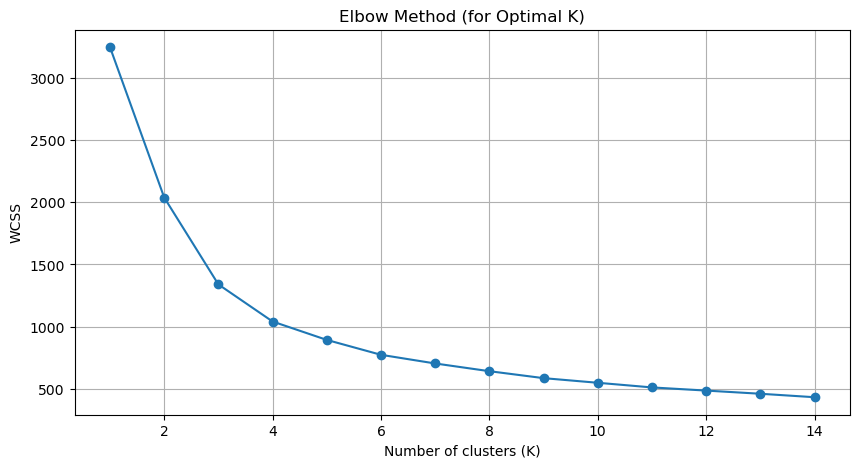

C:\Users\rina3\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(



✅ 클러스터링 완료! 최적 K=10로 군집화되었습니다.

--- 클러스터별 저수지 개수 ---
Cluster
0    151
1     45
2     10
3     78
4    106
5    142
6    105
7     97
8     66
9     12
Name: 저수지ID, dtype: int64

[다음 단계: df_clustered 데이터를 기반으로 LSTM 모델 학습]


In [4]:
# ----------------------------------------------------
# 3단계: K-means 클러스터링
# ----------------------------------------------------
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 3-1. 최적 K 찾기 (Elbow Method)
X = features_for_clustering.values
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X) # 최종적으로 사용할 표준화된 특징 데이터

wcss = [] # Within-Cluster Sum of Squares
max_k = 15 # 클러스터 개수 탐색 범위 (15개 이하로 설정)

for i in range(1, max_k):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, max_k), wcss, marker='o')
plt.title('Elbow Method (for Optimal K)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

# 3-2. 최종 K 선택 및 K-means 적용
# Elbow Method 결과 그래프를 확인하여 K를 결정
# (예시: 그래프를 보고 K=8 또는 K=10을 선택했다고 가정)
optimal_k = 10 # <<<<<< 이 값을 그래프를 보고 결정..해야하는데 걍 10으로 진행

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# 3-3. 클러스터 결과 저장 및 병합
cluster_results = pd.DataFrame({
    '저수지ID': final_features.index,
    'Cluster': clusters
})

# 3-4. 원본 클린 데이터에 클러스터 결과 병합
df_clustered = pd.merge(df_clean, cluster_results, on='저수지ID')

print(f"\n✅ 클러스터링 완료! 최적 K={optimal_k}로 군집화되었습니다.")
print("\n--- 클러스터별 저수지 개수 ---")
print(df_clustered.groupby('Cluster')['저수지ID'].nunique().sort_index())
print("\n[다음 단계: df_clustered 데이터를 기반으로 LSTM 모델 학습]")

## [4] 특징 정보 추가

In [5]:
# ----------------------------------------------------
# A. Sine/Cosine 변환 함수 정의
# ----------------------------------------------------
import numpy as np

def create_cyclical_features(df):
    # '월' 정보 추출
    df['Month'] = df['날짜'].dt.month
    
    # 월을 Sine/Cosine으로 변환 (12월과 1월이 가깝게 만듦)
    df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
    df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)
    
    # 원본 'Month' 컬럼은 제거
    df = df.drop(columns=['Month'])
    
    return df

# ----------------------------------------------------
# B. df_clustered에 특징 적용
# ----------------------------------------------------
# 현재 메모리에 로드된 df_clustered 변수에 적용합니다.
df_clustered = create_cyclical_features(df_clustered.copy())

print("✅ 계절성 특징 (Month_Sin, Month_Cos) 추가 완료.")
print(f"새로운 특징 컬럼: {df_clustered.columns}")

✅ 계절성 특징 (Month_Sin, Month_Cos) 추가 완료.
새로운 특징 컬럼: Index(['저수지ID', '저수지명', '위치', '경도', '위도', '유효저수량(천m3)', '날짜', '저수율', 'Cluster',
       'Month_Sin', 'Month_Cos'],
      dtype='object')


In [8]:
import pandas as pd
import numpy as np

# df_clustered 변수가 메모리에 있다고 가정합니다. (이전 단계 실행 필수)
if 'df_clustered' not in locals():
    print("❌ ERROR: df_clustered 변수가 메모리에 없습니다. 이전 단계를 다시 실행하여 df_clustered를 먼저 로드/생성하십시오.")
else:
    # 1. 월별 및 저수지별 최대/최소 저수율 계산 (패턴의 크기)
    monthly_stats = df_clustered.groupby(['저수지ID', df_clustered['날짜'].dt.month])['저수율'].agg(
        Max_Rate=('max'),
        Min_Rate=('min')
    ).reset_index()
    
    monthly_stats = monthly_stats.rename(columns={'날짜': 'Month'})
    
    # 2. df_clustered에 Month 컬럼을 임시로 추가하여 병합 준비
    df_clustered['Month'] = df_clustered['날짜'].dt.month
    
    # 3. 새로운 특징을 df_clustered에 병합 
    df_clustered = pd.merge(
        df_clustered, 
        monthly_stats, 
        on=['저수지ID', 'Month'], 
        how='left'
    )
    
    # 4. 임시 Month 컬럼 제거
    df_clustered = df_clustered.drop(columns=['Month'])
    
    # 5. 컬럼 이름 통일
    df_clustered = df_clustered.rename(columns={'Max_Rate': 'Month_Max_Rate', 'Min_Rate': 'Month_Min_Rate'})
    
    print("✅ 새로운 특징 'Month_Max_Rate' 및 'Month_Min_Rate'가 df_clustered에 추가되었습니다.")
    print(f"총 특징 수: {len(df_clustered.columns)}")

✅ 새로운 특징 'Month_Max_Rate' 및 'Month_Min_Rate'가 df_clustered에 추가되었습니다.
총 특징 수: 13


## [5] 모델 정의

In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential, load_model, save_model
from tensorflow.keras.layers import Layer, Dense, Dropout, LayerNormalization, MultiHeadAttention
from tensorflow.keras import Input 
from tensorflow.keras.callbacks import EarlyStopping
import joblib
import os
from tqdm.notebook import tqdm

# =================================================================
# 1. 트랜스포머 모델 구성 요소 정의 (필수)
# =================================================================
class MultiHeadAttentionLayer(Layer):
    def __init__(self, d_model, num_heads, **kwargs): 
        super(MultiHeadAttentionLayer, self).__init__(**kwargs)
        self.attn = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.layernorm = LayerNormalization(epsilon=1e-6)
        self.dropout = Dropout(0.1)
    def call(self, inputs, training=False):
        attn_output = self.attn(query=inputs, value=inputs, key=inputs)
        attn_output = self.dropout(attn_output, training=training)
        output = self.layernorm(inputs + attn_output)
        return output

class TransformerBlock(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.att = MultiHeadAttentionLayer(d_model, num_heads)
        self.ffn = Sequential([Dense(dff, activation='relu'), Dense(d_model)])
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout2 = Dropout(rate)
    def call(self, inputs, training=False):
        attn_output = self.att(inputs, training=training) 
        ffn_output = self.ffn(attn_output)
        ffn_output = self.dropout2(ffn_output, training=training)
        output = self.layernorm2(attn_output + ffn_output) 
        return output

def create_transformer_model_v5(sequence_length, n_features, d_model=7, num_heads=1, dff=14, num_layers=2):
    d_model = n_features
    num_heads = 1 
    dff = n_features * 2
    inputs = Input(shape=(sequence_length, n_features))
    x = inputs
    for _ in range(num_layers):
        x = TransformerBlock(d_model, num_heads, dff)(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    outputs = Dense(1)(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

def create_sequences_v5(data, sequence_length, target_column='feature_0'):
    X, y = [], []
    # feature_0: 저수율(S), feature_1: 위도(S), ..., feature_6: Cos(NS)
    FEATURE_COLUMNS = [f'feature_{i}' for i in range(7)] 
    
    for reservoir_id, group in data.groupby('저수지ID'):
        features = group[FEATURE_COLUMNS].values 
        if len(features) < sequence_length + 1:
            continue 
        for i in range(len(features) - sequence_length):
            X.append(features[i:(i + sequence_length)])
            y.append(group[target_column].iloc[i + sequence_length])
            
    return np.array(X), np.array(y)

## [6] 모델학습

In [37]:
# --- 학습 환경 설정 변수 ---
BASE_MODEL_DIR = 'transformer_seasonal_v5'
SCALER_DIR = 'scalers_seasonal_v5'


os.makedirs(BASE_MODEL_DIR, exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)

N_CLUSTERS = 10 
SEQUENCE_LENGTH = 30  
train_end_date = pd.to_datetime('2023-12-31') 

# 분리된 특징 정의
RATE_FEATURE = ['저수율'] # 스케일러 1 (저수율)
OTHER_SCALED_FEATURES = ['위도', '경도', 'Month_Max_Rate', 'Month_Min_Rate'] # 스케일러 2 (4개 특징)

# 학습 시작
cluster_range = range(N_CLUSTERS)
print(f"총 {N_CLUSTERS}개 클러스터 모델 V5 트랜스포머 재학습 시작.")

if 'df_clustered' not in locals():
    print("❌ ERROR: df_clustered 변수가 메모리에 없습니다. 데이터 복구 및 특징 추가 단계를 먼저 실행하십시오.")
else:
    for cluster_id in tqdm(cluster_range, desc="전체 클러스터 V5 학습 진행"):
        
        cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id].copy()

        # 데이터 안정성 강화 (NaN/Inf 제거)
        cluster_data = cluster_data.dropna(subset=RATE_FEATURE + OTHER_SCALED_FEATURES + ['Month_Sin', 'Month_Cos']) 
        cluster_data = cluster_data[~cluster_data.isin([np.inf, -np.inf]).any(axis=1)] 
        
        if cluster_data.empty:
            tqdm.write(f"[SKIP] Cluster {cluster_id} 데이터가 부족하거나 정제 후 남아있지 않습니다.")
            continue

        # 2. 데이터 정규화 및 스케일러 설정 (MinMaxScaler 사용)
        
        # 2-1. 훈련 데이터 분리
        train_rate_for_fit = cluster_data[cluster_data['날짜'] <= train_end_date][RATE_FEATURE].values
        train_other_for_fit = cluster_data[cluster_data['날짜'] <= train_end_date][OTHER_SCALED_FEATURES].values

        # SCALER 1: 저수율 ([0, 100] 강제 고정) 
        rate_scaler = MinMaxScaler()
        # 저수율 스케일링을 [0, 100]으로 강제 고정
        rate_scaler.fit(np.array([[0], [100]])) 
        rate_scaled_np = rate_scaler.transform(cluster_data[RATE_FEATURE].values)
        
        # SCALER 2: 기타 특징 (훈련 데이터 범위 사용)
        feature_scaler = MinMaxScaler()
        feature_scaler.fit(train_other_for_fit) 
        other_scaled_np = feature_scaler.transform(cluster_data[OTHER_SCALED_FEATURES].values)

        
        # Non-Scaled 데이터 준비 (Month_Sin, Month_Cos)
        non_scaled_data_np = cluster_data[['Month_Sin', 'Month_Cos']].values
        
        # 최종 데이터 결합: [저수율_S, 위도_S, 경도_S, MaxRate_S, MinRate_S, Sin_NS, Cos_NS]
        final_cluster_data_np = np.hstack([rate_scaled_np, other_scaled_np, non_scaled_data_np])

        # DataFrame 형태로 변환하여 학습/검증 데이터 분리 
        df_temp = pd.DataFrame(final_cluster_data_np, columns=[f'feature_{i}' for i in range(7)])
        df_temp['날짜'] = cluster_data['날짜'].values
        df_temp['저수지ID'] = cluster_data['저수지ID'].values 
        
        train_data = df_temp[df_temp['날짜'] <= train_end_date].drop(columns=['날짜'])
        val_data = df_temp[df_temp['날짜'] > train_end_date].drop(columns=['날짜'])

        # 4. 시퀀스 변환
        X_train, y_train = create_sequences_v5(train_data, SEQUENCE_LENGTH, target_column='feature_0')
        X_val, y_val = create_sequences_v5(val_data, SEQUENCE_LENGTH, target_column='feature_0')
        
        if X_train.size == 0 or X_val.size == 0:
            tqdm.write(f"[SKIP] Cluster {cluster_id}: 시퀀스를 만들기에 데이터가 부족합니다.")
            continue
            
        n_features = X_train.shape[2] 
        model = create_transformer_model_v5(SEQUENCE_LENGTH, n_features) 

        # 5. 모델 학습 (Verbose=1 적용)
        tqdm.write(f"\n--- Cluster {cluster_id} 학습 시작 ---")
        history = model.fit(
            X_train, y_train,
            epochs=50,                  
            batch_size=32,
            validation_data=(X_val, y_val),
            callbacks=[EarlyStopping(patience=5, restore_best_weights=True)],
            verbose=1 
        )
        
        # 6. 모델 및 스케일러 파일로 저장 (두 개의 스케일러 저장)
        model_filename = f'transformer_model_cluster_{cluster_id}_v5.h5'
        rate_scaler_filename = f'rate_scaler_cluster_{cluster_id}_v5.pkl'
        feature_scaler_filename = f'feature_scaler_cluster_{cluster_id}_v5.pkl'
        
        model.save(os.path.join(BASE_MODEL_DIR, model_filename))
        
        # 분리된 두 개의 스케일러 저장
        joblib.dump(rate_scaler, os.path.join(SCALER_DIR, rate_scaler_filename))
        joblib.dump(feature_scaler, os.path.join(SCALER_DIR, feature_scaler_filename))
        
        tqdm.write(f"✅ Cluster {cluster_id} V5 트랜스포머 재학습 완료. 최종 val_loss: {history.history['val_loss'][-1]:.6f}")

print("\n[SUCCESS] 모든 클러스터에 대한 V5 트랜스포머 모델 학습 및 저장 완료.")

총 10개 클러스터 모델 V5 트랜스포머 재학습 시작.


전체 클러스터 V5 학습 진행:   0%|          | 0/10 [00:00<?, ?it/s]


--- Cluster 0 학습 시작 ---
Epoch 1/50
5026/5026 ━━━━━━━━━━━━━━━━━━━━ 56s 10ms/step - loss: 0.0121 - val_loss: 0.0058
Epoch 2/50
5026/5026 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - loss: 0.0035 - val_loss: 0.0041
Epoch 3/50
5026/5026 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - loss: 0.0028 - val_loss: 0.0042
Epoch 4/50
5026/5026 ━━━━━━━━━━━━━━━━━━━━ 47s 9ms/step - loss: 0.0026 - val_loss: 0.0038
Epoch 5/50
5026/5026 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - loss: 0.0024 - val_loss: 0.0038
Epoch 6/50
5026/5026 ━━━━━━━━━━━━━━━━━━━━ 88s 10ms/step - loss: 0.0023 - val_loss: 0.0035
Epoch 7/50
5026/5026 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - loss: 0.0022 - val_loss: 0.0035
Epoch 8/50
5026/5026 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - loss: 0.0022 - val_loss: 0.0037
Epoch 9/50
5026/5026 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - loss: 0.0022 - val_loss: 0.0036
Epoch 10/50
5026/5026 ━━━━━━━━━━━━━━━━━━━━ 85s 10ms/step - loss: 0.0021 - val_loss: 0.0036
Epoch 11/50
5026/5026 ━━━━━━━━━━━━━━━━━━━━ 52s 10ms/step - loss: 0.0021 - val_

✅ Cluster 0 V5 트랜스포머 재학습 완료. 최종 val_loss: 0.003500

--- Cluster 1 학습 시작 ---
Epoch 1/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step - loss: 0.0171 - val_loss: 0.0084
Epoch 2/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.0074 - val_loss: 0.0082
Epoch 3/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.0058 - val_loss: 0.0059
Epoch 4/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.0052 - val_loss: 0.0055
Epoch 5/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0049 - val_loss: 0.0053
Epoch 6/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - loss: 0.0046 - val_loss: 0.0060
Epoch 7/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - loss: 0.0045 - val_loss: 0.0049
Epoch 8/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.0043 - val_loss: 0.0064
Epoch 9/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.0042 - val_loss: 0.0051
Epoch 10/50
1498/1498 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - loss: 0.0041 - val_loss: 0.0060
Epoch 11/50
1498/1498 ━━━

✅ Cluster 1 V5 트랜스포머 재학습 완료. 최종 val_loss: 0.005247

--- Cluster 2 학습 시작 ---
Epoch 1/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 0.0321 - val_loss: 0.0133
Epoch 2/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0121 - val_loss: 0.0088
Epoch 3/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0078 - val_loss: 0.0080
Epoch 4/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0062 - val_loss: 0.0072
Epoch 5/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0049 - val_loss: 0.0055
Epoch 6/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0040 - val_loss: 0.0048
Epoch 7/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0036 - val_loss: 0.0054
Epoch 8/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0032 - val_loss: 0.0048
Epoch 9/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0029 - val_loss: 0.0041
Epoch 10/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0027 - val_loss: 0.0045
Epoch 11/50
333/333 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step -

...

✅ Cluster 5 V5 트랜스포머 재학습 완료. 최종 val_loss: 0.003159

--- Cluster 6 학습 시작 ---
Epoch 1/50
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - loss: 0.0362 - val_loss: 0.0135
Epoch 2/50
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 43s 11ms/step - loss: 0.0062 - val_loss: 0.0077
Epoch 3/50
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - loss: 0.0047 - val_loss: 0.0072
Epoch 4/50
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 0.0041 - val_loss: 0.0082
Epoch 5/50
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 0.0038 - val_loss: 0.0059
Epoch 6/50
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 0.0036 - val_loss: 0.0077
Epoch 7/50
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 43s 11ms/step - loss: 0.0035 - val_loss: 0.0067
Epoch 8/50
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - loss: 0.0033 - val_loss: 0.0068
Epoch 9/50
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - loss: 0.0032 - val_loss: 0.0073
Epoch 10/50
3495/3495 ━━━━━━━━━━━━━━━━━━━━ 40s 11ms/step - loss: 0.0031 - val_loss: 0.0073


✅ Cluster 6 V5 트랜스포머 재학습 완료. 최종 val_loss: 0.007346

--- Cluster 7 학습 시작 ---
Epoch 1/50
3229/3229 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - loss: 0.0249 - val_loss: 0.0085
Epoch 2/50
3229/3229 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 0.0034 - val_loss: 0.0058
Epoch 3/50
3229/3229 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - loss: 0.0025 - val_loss: 0.0043
Epoch 4/50
3229/3229 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 0.0022 - val_loss: 0.0043
Epoch 5/50
3229/3229 ━━━━━━━━━━━━━━━━━━━━ 47s 11ms/step - loss: 0.0020 - val_loss: 0.0049
Epoch 6/50
3229/3229 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 0.0019 - val_loss: 0.0041
Epoch 7/50
3229/3229 ━━━━━━━━━━━━━━━━━━━━ 33s 10ms/step - loss: 0.0018 - val_loss: 0.0028
Epoch 8/50
3229/3229 ━━━━━━━━━━━━━━━━━━━━ 42s 11ms/step - loss: 0.0018 - val_loss: 0.0033
Epoch 9/50
3229/3229 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - loss: 0.0017 - val_loss: 0.0044
Epoch 10/50
3229/3229 ━━━━━━━━━━━━━━━━━━━━ 45s 11ms/step - loss: 0.0017 - val_loss: 0.0032
Epoch 11/50
3229/3229 ━

✅ Cluster 7 V5 트랜스포머 재학습 완료. 최종 val_loss: 0.002933

--- Cluster 8 학습 시작 ---
Epoch 1/50
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 29s 10ms/step - loss: 0.0451 - val_loss: 0.0172
Epoch 2/50
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 0.0093 - val_loss: 0.0116
Epoch 3/50
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - loss: 0.0064 - val_loss: 0.0074
Epoch 4/50
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - loss: 0.0052 - val_loss: 0.0086
Epoch 5/50
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - loss: 0.0048 - val_loss: 0.0082
Epoch 6/50
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 24s 11ms/step - loss: 0.0046 - val_loss: 0.0086
Epoch 7/50
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - loss: 0.0044 - val_loss: 0.0079
Epoch 8/50
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 42s 10ms/step - loss: 0.0043 - val_loss: 0.0091


✅ Cluster 8 V5 트랜스포머 재학습 완료. 최종 val_loss: 0.009103

--- Cluster 9 학습 시작 ---
Epoch 1/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - loss: 0.0687 - val_loss: 0.0220
Epoch 2/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0235 - val_loss: 0.0217
Epoch 3/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0206 - val_loss: 0.0231
Epoch 4/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0176 - val_loss: 0.0181
Epoch 5/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0119 - val_loss: 0.0117
Epoch 6/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0067 - val_loss: 0.0077
Epoch 7/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0053 - val_loss: 0.0075
Epoch 8/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.0046 - val_loss: 0.0059
Epoch 9/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0042 - val_loss: 0.0062
Epoch 10/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0039 - val_loss: 0.0050
Epoch 11/50
400/400 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/ste

✅ Cluster 9 V5 트랜스포머 재학습 완료. 최종 val_loss: 0.003521

[SUCCESS] 모든 클러스터에 대한 V5 트랜스포머 모델 학습 및 저장 완료.


## [7] 모델 성능 평가

812개 전체 저수지에 대하여 시간이 오래걸리므로 (약 10시간) 각 클러스터별 랜덤 3개로 성능평가 진행

In [10]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Layer, Dense, Dropout, LayerNormalization, MultiHeadAttention
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
from tqdm import tqdm
from math import radians, sin, cos, sqrt, atan2

# =================================================================
# A. 파일 경로 및 설정
# =================================================================
BASE_MODEL_DIR = 'transformer_seasonal_v5'
SCALER_DIR = 'scalers_seasonal_v5'
SEQUENCE_LENGTH = 30
train_end_date = pd.to_datetime('2023-12-31') 

PREDICTION_FILE_2024 = '2024_evaluation_predictions_Sampled_V5.csv' 
ACTUAL_FILE_2024 = '2024_Actual_Reservoir_Rates.csv'         
SAMPLES_PER_CLUSTER = 3 # ⭐ 클러스터별 샘플링할 저수지 수

# 1. 트랜스포머 모델 구성 요소 정의 (Custom Layer)
class MultiHeadAttentionLayer(Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super(MultiHeadAttentionLayer, self).__init__(**kwargs)
        self.attn = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.layernorm = LayerNormalization(epsilon=1e-6)
        self.dropout = Dropout(0.1)
    def call(self, inputs, training=False):
        attn_output = self.attn(query=inputs, value=inputs, key=inputs)
        attn_output = self.dropout(attn_output, training=training)
        output = self.layernorm(inputs + attn_output)
        return output

class TransformerBlock(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.att = MultiHeadAttentionLayer(d_model, num_heads)
        self.ffn = Sequential([Dense(dff, activation='relu'), Dense(d_model)])
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout2 = Dropout(rate)
    def call(self, inputs, training=False):
        attn_output = self.att(inputs, training=training) 
        ffn_output = self.ffn(attn_output)
        ffn_output = self.dropout2(ffn_output, training=training)
        output = self.layernorm2(attn_output + ffn_output) 
        return output

# 2. 2024년 예측 실행 함수 (듀얼 스케일러 로직 적용)
def iterative_forecast_2024_transformer_v5(reservoir_data, cluster_id, sequence_length, base_dir_model, scaler_dir):
    
    model_filename = f'transformer_model_cluster_{cluster_id}_v5.h5'
    rate_scaler_filename = f'rate_scaler_cluster_{cluster_id}_v5.pkl'
    feature_scaler_filename = f'feature_scaler_cluster_{cluster_id}_v5.pkl'
    
    RATE_FEATURE = ['저수율'] 
    OTHER_SCALED_FEATURES = ['위도', '경도', 'Month_Max_Rate', 'Month_Min_Rate'] 
    NON_SCALED_FEATURES = ['Month_Sin', 'Month_Cos'] 
    FEATURE_COLUMNS = RATE_FEATURE + OTHER_SCALED_FEATURES + NON_SCALED_FEATURES
    
    N_FEATURES_IN_MODEL = 7
    N_RATE_SCALER_FEAT = 1
    PREDICTION_STEPS = 182 # 상반기 예측 (182일)

    # 1. 모델 및 스케일러 로드
    try:
        model = load_model(os.path.join(base_dir_model, model_filename), 
                           custom_objects={'MultiHeadAttentionLayer': MultiHeadAttentionLayer, 
                                             'TransformerBlock': TransformerBlock}, 
                           compile=False) 
        rate_scaler = joblib.load(os.path.join(scaler_dir, rate_scaler_filename))
        feature_scaler = joblib.load(os.path.join(scaler_dir, feature_scaler_filename))
    except Exception as e:
        return None, f"모델/스케일러 로드 실패 (오류: {e})"

    # 2. 초기 시퀀스 설정 (2023년 12월 31일까지의 데이터)
    train_end_date = pd.to_datetime('2023-12-31')
    initial_data_all = reservoir_data[reservoir_data['날짜'] <= train_end_date].copy()
    
    try:
        initial_data = initial_data_all[FEATURE_COLUMNS].values 
    except KeyError as e:
        return None, f"초기 시퀀스 생성 실패: 필수 컬럼 ({e}) 누락" 
        
    if len(initial_data) < sequence_length:
        return None, "데이터 부족"
        
    current_sequence_unscaled = initial_data[-sequence_length:].copy()
    
    # 데이터 스케일링
    rate_to_scale = current_sequence_unscaled[:, 0].reshape(-1, 1) 
    other_to_scale = current_sequence_unscaled[:, [1, 2, 3, 4]] 
    
    rate_scaled = rate_scaler.transform(rate_to_scale)
    other_scaled = feature_scaler.transform(other_to_scale)
    
    # 최종 입력 시퀀스 재구성
    current_sequence_scaled = np.zeros((sequence_length, N_FEATURES_IN_MODEL))
    current_sequence_scaled[:, 0] = rate_scaled.flatten()
    current_sequence_scaled[:, 1:5] = other_scaled 
    current_sequence_scaled[:, 5:7] = current_sequence_unscaled[:, 5:7] 
    
    # 3. 예측 루프
    predicted_rates = []
    current_date = pd.to_datetime('2024-01-01') 
    
    temp_df = reservoir_data[['날짜', 'Month_Max_Rate', 'Month_Min_Rate']].copy()
    
    for i in range(PREDICTION_STEPS): 
        X_input = current_sequence_scaled[-sequence_length:].reshape(1, sequence_length, N_FEATURES_IN_MODEL)
        predicted_scaled = model.predict(X_input, verbose=0)
        
        # 4. 역정규화
        dummy_rate_array = np.zeros((1, N_RATE_SCALER_FEAT))
        dummy_rate_array[:, 0] = predicted_scaled.flatten() 
        predicted_unscaled = rate_scaler.inverse_transform(dummy_rate_array)[0, 0]
        predicted_rates.append(predicted_unscaled)
        
        # 5. 시퀀스 업데이트를 위한 다음 날짜 특징 생성
        next_date = current_date + pd.Timedelta(days=1)
        next_month = next_date.month
        
        next_sin = np.sin(2 * np.pi * next_month / 12)
        next_cos = np.cos(2 * np.pi * next_month / 12)
        
        # Month_Max/Min_Rate 가져오기
        next_stats = temp_df[temp_df['날짜'] == next_date]
        next_max = next_stats['Month_Max_Rate'].iloc[0] if not next_stats.empty else 0
        next_min = next_stats['Month_Min_Rate'].iloc[0] if not next_stats.empty else 0
        
        # 다음 날짜의 위도, 경도 (unscaled 시퀀스에서 가져옴)
        lat_lon_unscaled = current_sequence_unscaled[-1, 1:3] 
        
        # OTHER_SCALED_FEATURES 스케일링 입력 구성
        other_scale_input = np.array([[lat_lon_unscaled[0], lat_lon_unscaled[1], next_max, next_min]])
        scaled_other_features = feature_scaler.transform(other_scale_input)[0]

        # 6. 다음 날 입력 벡터 구성
        new_feature_vector = np.concatenate([
            predicted_scaled.flatten(), 
            scaled_other_features,     
            np.array([next_sin, next_cos]) 
        ])
        
        # 시퀀스 갱신 (Scaled sequence)
        current_sequence_scaled = np.vstack([current_sequence_scaled[1:], new_feature_vector.reshape(1, -1)])
        
        # Unscaled sequence 업데이트 
        current_sequence_unscaled = np.vstack([
            current_sequence_unscaled[1:], 
            np.array([predicted_unscaled, lat_lon_unscaled[0], lat_lon_unscaled[1], 
                      next_sin, next_cos, next_max, next_min]).reshape(1, -1)
        ])

        current_date = next_date 

    final_predictions = np.clip(predicted_rates, 0, 100)
    
    return final_predictions.tolist(), "성공"

# =================================================================
# B. 2024년 실제값 추출 및 예측 실행 메인 루프 (랜덤 샘플링 평가)
# =================================================================

# 0. 필수 컬럼 체크
REQUIRED_COLUMNS = ['Month_Max_Rate', 'Month_Min_Rate', 'Month_Sin', 'Month_Cos', 'Cluster']
if 'df_clustered' not in locals() or not all(col in df_clustered.columns for col in REQUIRED_COLUMNS):
    print("❌ ERROR: 'df_clustered' 변수가 메모리에 없거나 필수 특징 컬럼이 누락되었습니다.")
    print("성능 평가를 진행하기 전에 Jupyter Notebook의 클러스터링 및 특징 추가 셀(Code Cell 20, 21, 22, 23)을 먼저 실행해야 합니다.")
    exit()

# ⭐⭐⭐ 1. 클러스터별 랜덤 샘플링 실행 ⭐⭐⭐
np.random.seed(42) # 재현성을 위해 시드 고정

try:
    sampled_ids = df_clustered.groupby('Cluster')['저수지ID'].apply(
        lambda x: x.sample(min(len(x), SAMPLES_PER_CLUSTER), random_state=42)
    ).tolist()
    EVALUATION_RESERVOIR_IDS = sampled_ids
    
    print("✅ 클러스터별 랜덤 샘플링 완료.")
    print(f"총 {len(EVALUATION_RESERVOIR_IDS)}개의 대표 저수지를 평가합니다.")
    
except Exception as e:
    print(f"❌ ERROR: 클러스터별 랜덤 샘플링 중 오류 발생: {e}")
    exit()
    
# 2. 2024년 실제값 파일 생성 (상반기 기준)
df_actual_2024_base = df_clustered[df_clustered['날짜'].dt.year == 2024].copy()
df_actual_2024_base.rename(columns={'저수율': '실제_저수율'}, inplace=True)

df_actual_2024_base = df_actual_2024_base[df_actual_2024_base['날짜'] <= pd.to_datetime('2024-06-30')].copy()
df_actual_2024_base[['저수지ID', '날짜', '실제_저수율']].to_csv(ACTUAL_FILE_2024, index=False, encoding='utf-8')
print(f"✅ 2024년 상반기 실제값 데이터가 '{ACTUAL_FILE_2024}'로 저장되었습니다.")

# 3. 2024년 상반기 예측 실행 (샘플링된 저수지)
total_reservoirs = len(EVALUATION_RESERVOIR_IDS)
all_predictions_2024 = []

print(f"\n--- 2024년 상반기 (랜덤 샘플 {total_reservoirs}개 저수지) 예측 시작 (V5 모델) ---")

progress_bar = tqdm(EVALUATION_RESERVOIR_IDS, desc="2024년 상반기 예측 진행")

for reservoir_id in progress_bar:
    progress_bar.set_postfix_str(f"현재 저수지: {reservoir_id}")
    
    reservoir_data_target = df_clustered[df_clustered['저수지ID'] == reservoir_id].sort_values('날짜')
    
    if reservoir_data_target.empty:
        continue
        
    cluster_id = reservoir_data_target['Cluster'].iloc[0]
    
    model_path = os.path.join(BASE_MODEL_DIR, f'transformer_model_cluster_{cluster_id}_v5.h5')
    if not os.path.exists(model_path):
         continue
        
    predictions, status = iterative_forecast_2024_transformer_v5(
        reservoir_data=reservoir_data_target, 
        cluster_id=cluster_id, 
        sequence_length=SEQUENCE_LENGTH,
        base_dir_model=BASE_MODEL_DIR,
        scaler_dir=SCALER_DIR
    )
    
    if status != "성공":
        continue

    if predictions:
        prediction_start_date = pd.to_datetime('2024-01-01')
        date_range = pd.date_range(start=prediction_start_date, periods=len(predictions), freq='D')
        
        df_forecast = pd.DataFrame({
            '저수지ID': reservoir_id,
            '날짜': date_range,
            '예측_저수율': [round(p, 2) for p in predictions] 
        })
        all_predictions_2024.append(df_forecast)
        
if all_predictions_2024:
    df_final_forecast_2024 = pd.concat(all_predictions_2024, ignore_index=True)
    df_final_forecast_2024.to_csv(PREDICTION_FILE_2024, index=False, encoding='utf-8') 
    print(f"\n✅ [SUCCESS] 2024년 상반기 예측 결과가 '{PREDICTION_FILE_2024}'로 저장되었습니다.")
else:
    print("\n❌ [FAILURE] 예측에 성공한 저수지가 없어 평가를 진행할 수 없습니다.")
    exit()

# 4. 성능 지표 계산
df_pred = df_final_forecast_2024.copy()
df_actual = pd.read_csv(ACTUAL_FILE_2024) 

df_pred['날짜'] = pd.to_datetime(df_pred['날짜'])
df_actual['날짜'] = pd.to_datetime(df_actual['날짜'])

PREDICTION_COL = '예측_저수율'
ACTUAL_COL = '실제_저수율' 

df_merged = pd.merge(
    df_pred,
    df_actual[['저수지ID', '날짜', ACTUAL_COL]],
    on=['저수지ID', '날짜'],
    how='inner' 
)

df_eval = df_merged.dropna(subset=[PREDICTION_COL, ACTUAL_COL]).copy()
df_eval = df_eval[df_eval[ACTUAL_COL] > 0.0]

n_samples = len(df_eval)
if n_samples == 0:
    print("❌ ERROR: 평가 가능한 유효 데이터 쌍이 없어 성능 평가를 완료할 수 없습니다.")
    exit()
    
y_true = df_eval[ACTUAL_COL].values
y_pred = df_eval[PREDICTION_COL].values

# 지표 계산
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print("\n========================================================================")
print(f"** 📈 최종 모델 성능 평가 결과 (기준: 2024년 상반기 랜덤 샘플 {total_reservoirs}개 Test Set) **")
print(f"------------------------------------------------------------------------")
print(f"총 평가 샘플 수 (저수지 x 날짜): {n_samples}개")
print(f"1. RMSE (제곱근 평균 제곱 오차): {rmse:.4f}")
print(f"2. MAE (평균 절대 오차): {mae:.4f}")
print("========================================================================")

print("\n[결과 해석 가이드]")
print(f"* MAE {mae:.2f}는 예측 저수율이 실제 저수율과 평균 {mae:.2f}%p 차이가 남을 의미합니다.")

✅ 클러스터별 랜덤 샘플링 완료.
총 30개의 대표 저수지를 평가합니다.
✅ 2024년 상반기 실제값 데이터가 '2024_Actual_Reservoir_Rates.csv'로 저장되었습니다.

--- 2024년 상반기 (랜덤 샘플 30개 저수지) 예측 시작 (V5 모델) ---


2024년 상반기 예측 진행: 100%|██████████| 30/30 [10:45<00:00, 21.52s/it, 현재 저수지: 상하_인천광역시]     



✅ [SUCCESS] 2024년 상반기 예측 결과가 '2024_evaluation_predictions_Sampled_V5.csv'로 저장되었습니다.

** 📈 최종 모델 성능 평가 결과 (기준: 2024년 상반기 랜덤 샘플 30개 Test Set) **
------------------------------------------------------------------------
총 평가 샘플 수 (저수지 x 날짜): 5460개
1. RMSE (제곱근 평균 제곱 오차): 10.6978
2. MAE (평균 절대 오차): 6.4665

[결과 해석 가이드]
* MAE 6.47는 예측 저수율이 실제 저수율과 평균 6.47%p 차이가 남을 의미합니다.


## [8] 2026 예측 함수 정의

In [11]:
def iterative_forecast_2026_transformer_v5(reservoir_data, cluster_id, sequence_length, base_dir_model, scaler_dir):
    """
    트랜스포머 V5 모델을 사용하여 2026년 전체 (366일) 반복 예측을 수행합니다.
    (저수율 스케일링 범위 [0, 100] 고정 모델 사용)
    """
    model_filename = f'transformer_model_cluster_{cluster_id}_v5.h5'
    rate_scaler_filename = f'rate_scaler_cluster_{cluster_id}_v5.pkl'
    feature_scaler_filename = f'feature_scaler_cluster_{cluster_id}_v5.pkl'
    
    # 7개 특징 정의
    RATE_FEATURE = ['저수율'] # 1개, Index 0
    OTHER_SCALED_FEATURES = ['위도', '경도', 'Month_Max_Rate', 'Month_Min_Rate'] # 4개, Index 1~4
    NON_SCALED_FEATURES = ['Month_Sin', 'Month_Cos'] # 2개, Index 5~6
    FEATURE_COLUMNS = RATE_FEATURE + OTHER_SCALED_FEATURES + NON_SCALED_FEATURES
    
    # 인덱스 정의
    OTHER_SCALED_FEATURES_IDX = [1, 2, 5, 6] # 7개 중 위도, 경도, Max, Min의 원본 인덱스
    N_FEATURES_IN_MODEL = 7
    N_RATE_SCALER_FEAT = 1 # 저수율 스케일러가 학습한 특징 개수

    PREDICTION_STEPS = 366 # 2026년 윤년

    # 1. 모델 및 스케일러 로드
    try:
        model = load_model(os.path.join(base_dir_model, model_filename), 
                           custom_objects={'MultiHeadAttentionLayer': MultiHeadAttentionLayer, 
                                             'TransformerBlock': TransformerBlock}, 
                           compile=False) 
        rate_scaler = joblib.load(os.path.join(scaler_dir, rate_scaler_filename))
        feature_scaler = joblib.load(os.path.join(scaler_dir, feature_scaler_filename))
    except Exception as e:
        return None, f"모델/스케일러 로드 실패 (오류: {e})"

    # 2. 초기 시퀀스 설정 (2024년 12월 31일까지의 데이터)
    initial_data = reservoir_data[FEATURE_COLUMNS].values
    
    if len(initial_data) < sequence_length:
        return None, "데이터 부족"
        
    current_sequence_unscaled = initial_data[-sequence_length:].copy()
    
    # 데이터 스케일링
    rate_to_scale = current_sequence_unscaled[:, 0].reshape(-1, 1) # 저수율
    other_to_scale = current_sequence_unscaled[:, OTHER_SCALED_FEATURES_IDX] # 위도, 경도, Max, Min
    
    rate_scaled = rate_scaler.transform(rate_to_scale)
    other_scaled = feature_scaler.transform(other_to_scale)
    
    # 최종 입력 시퀀스 재구성: [Rate_S, Other_S (4개), Non_S (2개)]
    current_sequence_scaled = np.zeros((sequence_length, N_FEATURES_IN_MODEL))
    current_sequence_scaled[:, 0] = rate_scaled.flatten()
    current_sequence_scaled[:, 1:5] = other_scaled 
    current_sequence_scaled[:, 5:7] = current_sequence_unscaled[:, 5:7] # Sin/Cos
    
    # 3. 예측 루프
    predicted_rates = []
    current_date = pd.to_datetime('2026-01-01') 
    
    temp_df = reservoir_data[['날짜', 'Month_Max_Rate', 'Month_Min_Rate']].copy()
    
    for i in range(PREDICTION_STEPS):
        X_input = current_sequence_scaled[-sequence_length:].reshape(1, sequence_length, N_FEATURES_IN_MODEL)
        predicted_scaled = model.predict(X_input, verbose=0)
        
        # 4. 역정규화 (저수율 스케일러 사용)
        dummy_rate_array = np.zeros((1, N_RATE_SCALER_FEAT))
        dummy_rate_array[:, 0] = predicted_scaled.flatten() 
        predicted_unscaled = rate_scaler.inverse_transform(dummy_rate_array)[0, 0]
        predicted_rates.append(predicted_unscaled)
        
        # 5. 시퀀스 업데이트를 위한 다음 날짜 특징 생성
        next_date = current_date + pd.Timedelta(days=1)
        next_month = next_date.month
        
        next_sin = np.sin(2 * np.pi * next_month / 12)
        next_cos = np.cos(2 * np.pi * next_month / 12)
        
        # Month_Max/Min_Rate 가져오기
        next_stats = temp_df[temp_df['날짜'] == next_date]
        next_max = next_stats['Month_Max_Rate'].iloc[0] if not next_stats.empty else 0
        next_min = next_stats['Month_Min_Rate'].iloc[0] if not next_stats.empty else 0
        
        # 다음 날짜의 위도, 경도 (unscaled 시퀀스에서 가져옴)
        lat_lon_unscaled = current_sequence_unscaled[-1, 1:3] 
        
        # OTHER_SCALED_FEATURES (위도, 경도, Max, Min) 스케일링 입력 구성
        other_scale_input = np.array([[lat_lon_unscaled[0], lat_lon_unscaled[1], next_max, next_min]])
        
        # feature_scaler를 사용하여 스케일링
        scaled_other_features = feature_scaler.transform(other_scale_input)[0]

        # 6. 다음 날 입력 벡터 구성
        new_feature_vector = np.concatenate([
            predicted_scaled.flatten(), # 저수율 (Scaled)
            scaled_other_features,     # 위도, 경도, Max, Min (Scaled)
            np.array([next_sin, next_cos]) # Sin, Cos (Non-Scaled)
        ])
        
        # 시퀀스 갱신 (Scaled sequence)
        current_sequence_scaled = np.vstack([current_sequence_scaled[1:], new_feature_vector.reshape(1, -1)])
        
        # Unscaled sequence 업데이트 (다음 반복 및 Max/Min 업데이트에 사용)
        current_sequence_unscaled = np.vstack([
            current_sequence_unscaled[1:], 
            np.array([predicted_unscaled, lat_lon_unscaled[0], lat_lon_unscaled[1], 
                      next_sin, next_cos, next_max, next_min]).reshape(1, -1)
        ])

        current_date = next_date 

    # 저수율을 [0, 100] 범위로 클리핑하여 최종 예측 결과의 안정성 보장
    final_predictions = np.clip(predicted_rates, 0, 100)
    
    return final_predictions.tolist(), "성공"

## [9] 2026 전체 저수지 저수율 예측

### [9-1] 예측 확인: 강원도 강릉시 오봉 저수지

In [39]:
# =================================================================
# 4. 2026년 오봉 저수지 예측 실행 루프
# =================================================================
SEQUENCE_LENGTH = 30
TARGET_ID = '오봉_강원도 강릉시'
BASE_MODEL_DIR = 'transformer_seasonal_v5'
SCALER_DIR = 'scalers_seasonal_v5'        
OUTPUT_FILE_2026 = '오봉_강원도_강릉시_2026년_예측_결과_V5.csv'

# df_clustered 변수 확인
if 'df_clustered' not in locals() or df_clustered.empty:
    print("❌ ERROR: df_clustered 변수가 메모리에 없습니다. 데이터 복구 단계를 먼저 실행하십시오.")
else:
    reservoir_data_target = df_clustered[df_clustered['저수지ID'] == TARGET_ID].sort_values('날짜')
    
    if reservoir_data_target.empty:
        print(f"❌ ERROR: 저수지ID '{TARGET_ID}'에 대한 데이터가 df_clustered에 없습니다.")
    else:
        cluster_id = reservoir_data_target['Cluster'].iloc[0]
        
        print(f"'{TARGET_ID}' 저수지의 클러스터 ID: {cluster_id}")
        print("\n--- 예측 시작: 2026-01-01부터 2026년 12월 31일까지 (트랜스포머 V5 모델) ---")

        predictions, status = iterative_forecast_2026_transformer_v5(
            reservoir_data=reservoir_data_target, 
            cluster_id=cluster_id, 
            sequence_length=SEQUENCE_LENGTH,
            base_dir_model=BASE_MODEL_DIR,
            scaler_dir=SCALER_DIR
        )

        if status == "성공":
            prediction_start_date = pd.to_datetime('2026-01-01')
            date_range = pd.date_range(start=prediction_start_date, periods=len(predictions), freq='D')
            
            df_forecast = pd.DataFrame({
                '날짜': date_range,
                '예측_저수율': predictions
            })
            
            # 월별 평균 저수율 계산 로직
            df_forecast['월'] = df_forecast['날짜'].dt.month
            monthly_avg = df_forecast.groupby('월')['예측_저수율'].mean().reset_index()
            monthly_avg.columns = ['월', '평균_예측_저수율']
            monthly_avg['평균_예측_저수율'] = monthly_avg['평균_예측_저수율'].round(2)

            month_name_map = {i: f'{i}월' for i in range(1, 13)}
            monthly_avg['월'] = monthly_avg['월'].map(month_name_map)
            
            # 월별 평균 결과 출력
            print("\n=========================================================")
            print(f"    ✅ 2026년 {TARGET_ID} 월별 평균 예측 저수율 (트랜스포머 V5)")
            print("=========================================================")
            print(monthly_avg.to_markdown(index=False))
            print("=========================================================\n")
            
            df_forecast.to_csv(OUTPUT_FILE_2026, index=False, encoding='utf-8')
            print(f"✅ 2026년 전체 예측 결과가 '{OUTPUT_FILE_2026}'로 저장되었습니다.")
        else:
            print(f"\n❌ 2026년 예측 실패: {status}")

'오봉_강원도 강릉시' 저수지의 클러스터 ID: 6

--- 예측 시작: 2026-01-01부터 2026년 12월 31일까지 (트랜스포머 V5 모델) ---

    ✅ 2026년 오봉_강원도 강릉시 월별 평균 예측 저수율 (트랜스포머 V5)
| 월   |   평균_예측_저수율 |
|:-----|-------------------:|
| 1월  |             100    |
| 2월  |              99.77 |
| 3월  |              75.5  |
| 4월  |              44.86 |
| 5월  |              34.49 |
| 6월  |              42.17 |
| 7월  |              56.84 |
| 8월  |              66.45 |
| 9월  |              77.56 |
| 10월 |              95.18 |
| 11월 |             100    |
| 12월 |             100    |

✅ 2026년 전체 예측 결과가 '오봉_강원도_강릉시_2026년_예측_결과_V5.csv'로 저장되었습니다.


### (9-2) 전체 저수지 2026 저수율 예측

In [40]:
import pandas as pd
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Layer, Dense, Dropout, LayerNormalization, MultiHeadAttention
import joblib
from tqdm import tqdm 

# =================================================================
# 1. 트랜스포머 모델 구성 요소 정의 (필수)
# =================================================================
class MultiHeadAttentionLayer(Layer):
    def __init__(self, d_model, num_heads, **kwargs):
        super(MultiHeadAttentionLayer, self).__init__(**kwargs)
        self.attn = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model // num_heads)
        self.layernorm = LayerNormalization(epsilon=1e-6)
        self.dropout = Dropout(0.1)

    def call(self, inputs, training=False):
        attn_output = self.attn(query=inputs, value=inputs, key=inputs)
        attn_output = self.dropout(attn_output, training=training)
        output = self.layernorm(inputs + attn_output)
        return output

class TransformerBlock(Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, **kwargs):
        super(TransformerBlock, self).__init__(**kwargs)
        self.att = MultiHeadAttentionLayer(d_model, num_heads)
        self.ffn = Sequential([
            Dense(dff, activation='relu'),
            Dense(d_model)
        ])
        self.layernorm2 = LayerNormalization(epsilon=1e-6)
        self.dropout2 = Dropout(rate)

    def call(self, inputs, training=False):
        attn_output = self.att(inputs, training=training) 
        ffn_output = self.ffn(attn_output)
        ffn_output = self.dropout2(ffn_output, training=training)
        output = self.layernorm2(attn_output + ffn_output) 
        return output
# =================================================================

def iterative_forecast_2026_transformer_v5(reservoir_data, cluster_id, sequence_length, base_dir_model, scaler_dir):
    """
    트랜스포머 V5 모델을 사용하여 2026년 전체 (366일) 반복 예측을 수행합니다.
    (듀얼 스케일러 로직 적용)
    """
    model_filename = f'transformer_model_cluster_{cluster_id}_v5.h5'
    rate_scaler_filename = f'rate_scaler_cluster_{cluster_id}_v5.pkl'
    feature_scaler_filename = f'feature_scaler_cluster_{cluster_id}_v5.pkl'
    
    # 7개 특징 정의
    RATE_FEATURE = ['저수율'] # 1개, Index 0
    OTHER_SCALED_FEATURES = ['위도', '경도', 'Month_Max_Rate', 'Month_Min_Rate'] # 4개, Index 1~4
    NON_SCALED_FEATURES = ['Month_Sin', 'Month_Cos'] # 2개, Index 5~6
    FEATURE_COLUMNS = RATE_FEATURE + OTHER_SCALED_FEATURES + NON_SCALED_FEATURES
    
    # 인덱스 정의
    OTHER_SCALED_FEATURES_IDX = [1, 2, 5, 6] # 원본 데이터에서 위도, 경도, Max, Min의 컬럼 인덱스 (저수율 제외)
    N_FEATURES_IN_MODEL = 7
    N_RATE_SCALER_FEAT = 1 
    PREDICTION_STEPS = 366 # 2026년 윤년

    # 1. 모델 및 스케일러 로드 (두 개의 스케일러 로드)
    try:
        model = load_model(os.path.join(base_dir_model, model_filename), 
                           custom_objects={'MultiHeadAttentionLayer': MultiHeadAttentionLayer, 
                                             'TransformerBlock': TransformerBlock}, 
                           compile=False) 
        rate_scaler = joblib.load(os.path.join(scaler_dir, rate_scaler_filename))
        feature_scaler = joblib.load(os.path.join(scaler_dir, feature_scaler_filename))
    except Exception as e:
        return None, f"모델/스케일러 로드 실패 (오류: {e})"

    # 2. 초기 시퀀스 설정 (2024년 12월 31일까지의 데이터)
    initial_data = reservoir_data[FEATURE_COLUMNS].values
    
    if len(initial_data) < sequence_length:
        return None, "데이터 부족"
        
    current_sequence_unscaled = initial_data[-sequence_length:].copy()
    
    # 데이터 스케일링
    rate_to_scale = current_sequence_unscaled[:, 0].reshape(-1, 1) 
    other_to_scale = current_sequence_unscaled[:, [1, 2, 3, 4]] # 위도, 경도, Max, Min (Unscaled Data)
    
    rate_scaled = rate_scaler.transform(rate_to_scale)
    other_scaled = feature_scaler.transform(other_to_scale)
    
    # 최종 입력 시퀀스 재구성: [Rate_S, Other_S (4개), Non_S (2개)]
    current_sequence_scaled = np.zeros((sequence_length, N_FEATURES_IN_MODEL))
    current_sequence_scaled[:, 0] = rate_scaled.flatten()
    current_sequence_scaled[:, 1:5] = other_scaled 
    current_sequence_scaled[:, 5:7] = current_sequence_unscaled[:, 5:7] # Sin/Cos
    
    # 3. 예측 루프
    predicted_rates = []
    current_date = pd.to_datetime('2026-01-01') 
    
    # Month_Max_Rate, Month_Min_Rate를 가져오기 위한 원본 데이터 (날짜와 값만 필요)
    temp_df = reservoir_data[['날짜', 'Month_Max_Rate', 'Month_Min_Rate']].copy()
    
    for i in range(PREDICTION_STEPS):
        X_input = current_sequence_scaled[-sequence_length:].reshape(1, sequence_length, N_FEATURES_IN_MODEL)
        predicted_scaled = model.predict(X_input, verbose=0)
        
        # 4. 역정규화 (저수율 스케일러 사용)
        dummy_rate_array = np.zeros((1, N_RATE_SCALER_FEAT))
        dummy_rate_array[:, 0] = predicted_scaled.flatten() 
        predicted_unscaled = rate_scaler.inverse_transform(dummy_rate_array)[0, 0]
        predicted_rates.append(predicted_unscaled)
        
        # 5. 시퀀스 업데이트를 위한 다음 날짜 특징 생성
        next_date = current_date + pd.Timedelta(days=1)
        next_month = next_date.month
        
        next_sin = np.sin(2 * np.pi * next_month / 12)
        next_cos = np.cos(2 * np.pi * next_month / 12)
        
        # Month_Max/Min_Rate 가져오기 (2026년 해당 날짜의 통계치)
        next_stats = temp_df[temp_df['날짜'] == next_date]
        next_max = next_stats['Month_Max_Rate'].iloc[0] if not next_stats.empty else 0
        next_min = next_stats['Month_Min_Rate'].iloc[0] if not next_stats.empty else 0
        
        # 다음 날짜의 위도, 경도 (unscaled 시퀀스에서 가져옴)
        lat_lon_unscaled = current_sequence_unscaled[-1, 1:3] 
        
        # OTHER_SCALED_FEATURES (위도, 경도, Max, Min) 스케일링 입력 구성
        other_scale_input = np.array([[lat_lon_unscaled[0], lat_lon_unscaled[1], next_max, next_min]])
        
        # feature_scaler를 사용하여 스케일링
        scaled_other_features = feature_scaler.transform(other_scale_input)[0]

        # 6. 다음 날 입력 벡터 구성
        new_feature_vector = np.concatenate([
            predicted_scaled.flatten(), # 저수율 (Scaled)
            scaled_other_features,     # 위도, 경도, Max, Min (Scaled)
            np.array([next_sin, next_cos]) # Sin, Cos (Non-Scaled)
        ])
        
        # 시퀀스 갱신 (Scaled sequence)
        current_sequence_scaled = np.vstack([current_sequence_scaled[1:], new_feature_vector.reshape(1, -1)])
        
        # Unscaled sequence 업데이트 
        current_sequence_unscaled = np.vstack([
            current_sequence_unscaled[1:], 
            np.array([predicted_unscaled, lat_lon_unscaled[0], lat_lon_unscaled[1], 
                      next_sin, next_cos, next_max, next_min]).reshape(1, -1)
        ])

        current_date = next_date 

    # 저수율을 [0, 100] 범위로 클리핑하여 최종 예측 결과의 안정성 보장
    final_predictions = np.clip(predicted_rates, 0, 100)
    
    return final_predictions.tolist(), "성공"

# =================================================================
# 4. 전체 저수지 예측 실행 루프
# =================================================================
SEQUENCE_LENGTH = 30
BASE_MODEL_DIR = 'transformer_seasonal_v5'
SCALER_DIR = 'scalers_seasonal_v5'
# 파일 경로 단순화 (루트 디렉토리에 저장)
FINAL_OUTPUT_FILE_2026 = '2026_Full_Reservoir_Forecasts_V5.csv'

if 'df_clustered' not in locals() or df_clustered.empty:
    print("\n❌ ERROR: 'df_clustered' 변수가 메모리에 없어 예측을 시작할 수 없습니다. 데이터를 먼저 복구해 주세요.")
else:
    unique_reservoir_ids = df_clustered['저수지ID'].unique()
    total_reservoirs = len(unique_reservoir_ids)
    all_predictions = []

    print(f"\n--- 2026년 전체 {total_reservoirs}개 저수지 예측 시작 (V5 모델) ---")
    
    # 진행률 표시 (tqdm 사용)
    progress_bar = tqdm(unique_reservoir_ids, desc="전체 예측 진행")
    
    for reservoir_id in progress_bar:
        
        # 현재 처리 중인 저수지 ID를 실시간으로 표시
        progress_bar.set_postfix_str(f"현재 저수지: {reservoir_id}")
        
        reservoir_data_target = df_clustered[df_clustered['저수지ID'] == reservoir_id].sort_values('날짜')
        cluster_id = reservoir_data_target['Cluster'].iloc[0]
        
        # 모델 및 스케일러 파일 존재 여부 확인
        model_path = os.path.join(BASE_MODEL_DIR, f'transformer_model_cluster_{cluster_id}_v5.h5')
        rate_scaler_path = os.path.join(SCALER_DIR, f'rate_scaler_cluster_{cluster_id}_v5.pkl')
        
        if not os.path.exists(model_path) or not os.path.exists(rate_scaler_path):
             continue
            
        # 2026년 예측 실행
        predictions, status = iterative_forecast_2026_transformer_v5(
            reservoir_data=reservoir_data_target, 
            cluster_id=cluster_id, 
            sequence_length=SEQUENCE_LENGTH,
            base_dir_model=BASE_MODEL_DIR,
            scaler_dir=SCALER_DIR
        )

        # 결과 저장
        if status == "성공" and predictions:
            prediction_start_date = pd.to_datetime('2026-01-01')
            date_range = pd.date_range(start=prediction_start_date, periods=len(predictions), freq='D')
            
            df_forecast = pd.DataFrame({
                '저수지ID': reservoir_id,
                '날짜': date_range,
                '예측_저수율': [round(p, 2) for p in predictions] # 소수점 둘째 자리까지 반올림하여 저장
            })
            all_predictions.append(df_forecast)
            
    # 모든 결과를 하나의 CSV 파일로 통합 저장
    if all_predictions:
        df_final_forecast = pd.concat(all_predictions, ignore_index=True)
        
        df_final_forecast.to_csv(FINAL_OUTPUT_FILE_2026, index=False, encoding='utf-8') 
        
        print(f"\n✅ [SUCCESS] 모든 저수지에 대한 2026년 전체 예측 결과가 '{FINAL_OUTPUT_FILE_2026}'로 저장되었습니다.")
        print(f"총 예측 데이터 수: {len(df_final_forecast):,} 행")
    else:
        print("\n❌ [FAILURE] 예측에 성공한 저수지가 없어 최종 파일을 생성하지 못했습니다.")


--- 2026년 전체 812개 저수지 예측 시작 (V5 모델) ---


전체 예측 진행: 100%|██████████| 812/812 [7:37:45<00:00, 33.82s/it, 현재 저수지: 흥업_강원도 원주시]           



✅ [SUCCESS] 모든 저수지에 대한 2026년 전체 예측 결과가 '2026_Full_Reservoir_Forecasts_V5.csv'로 저장되었습니다.
총 예측 데이터 수: 297,192 행


## [10] 저수지 매칭

### (10-1) 월별 부족 저수지 확인

In [49]:
import pandas as pd
import os
import numpy as np

# 1. 파일 경로 및 임계값 설정
FINAL_OUTPUT_FILE_2026 = '2026_Full_Reservoir_Forecasts_V5.csv'
LACK_THRESHOLD = 30.0    # 분석 기준: 30% 미만 (부족)
MIN_AVG_THRESHOLD = 10.0 # 분석 제외 기준 2: 월평균 10% 미만 (예측 오류로 간주)
DEVIATION_RATIO = 0.30   # 분석 제외 기준 3: 역사적 최소 저수율 대비 30% 초과 하락

# 2. 데이터 로드 및 준비
try:
    df_forecast = pd.read_csv(FINAL_OUTPUT_FILE_2026)
    df_forecast['날짜'] = pd.to_datetime(df_forecast['날짜'])
    
    # ⚠️ df_clustered 변수가 메모리에 있어야 합니다.
    if 'df_clustered' not in locals():
        print("❌ ERROR: 'df_clustered' 변수가 메모리에 없습니다. 역사적 최소 저수율 분석을 위해 이전 전처리 단계를 먼저 실행하십시오.")
        exit()
        
    df_history_min = df_clustered.groupby('저수지ID')['저수율'].min().reset_index()
    df_history_min.rename(columns={'저수율': 'History_Min_Rate'}, inplace=True)
    
    # 0% 예측값은 모든 월평균 계산에서 제외
    df_calc_base = df_forecast[df_forecast['예측_저수율'] > 0.0].copy()
    df_calc_base['월'] = df_calc_base['날짜'].dt.month
    
    # 모든 저수지에 대한 월별 평균 저수율 계산
    df_monthly_avg_full = df_calc_base.groupby(['저수지ID', '월'])['예측_저수율'].mean().reset_index()
    df_monthly_avg_full.columns = ['저수지ID', '월', '월별_평균_저수율']
    
    print(f"✅ 예측 파일 로드 완료 및 분석 준비 완료. (총 저수지 수: {df_forecast['저수지ID'].nunique()}개)")
    
except Exception as e:
    print(f"❌ ERROR: 데이터 로드/준비 중 오류 발생: {e}")
    exit()

# 3. 신뢰성 검증 1: "저수지 전체"를 제외할 목록 생성 (지역 및 안정성 기준)
excluded_full_reservoirs = set()

# 3-1. 제주도 지역 저수지 제외
jeju_ids = df_forecast[df_forecast['저수지ID'].str.contains('제주도', regex=False)]['저수지ID'].unique()
excluded_full_reservoirs.update(jeju_ids)

# 3-2. 역사적 최소 저수율 대비 과도한 하락 예측 저수지 제거 (안정성 미통과)
df_forecast_min = df_forecast.groupby('저수지ID')['예측_저수율'].min().reset_index()
df_forecast_min.rename(columns={'예측_저수율': 'Forecast_Min_Rate'}, inplace=True)

df_min_check = pd.merge(df_history_min, df_forecast_min, on='저수지ID', how='inner')
df_min_check = df_min_check[df_min_check['History_Min_Rate'] > 0.0].copy()

# Forecast_Min이 History_Min의 (1 - DEVIATION_RATIO) 이하인 경우
excessive_drop_ids = df_min_check[
    df_min_check['Forecast_Min_Rate'] < df_min_check['History_Min_Rate'] * (1 - DEVIATION_RATIO)
]['저수지ID'].unique()
excluded_full_reservoirs.update(excessive_drop_ids)

# 4. 최종 부족 저수지 목록 필터링
df_final_lacking = df_monthly_avg_full.copy()

# 4-1. 부족 임계값 (30% 미만) 필터링
df_final_lacking = df_final_lacking[df_final_lacking['월별_평균_저수율'] < LACK_THRESHOLD]

# 4-2. "저수지 전체" 제외 목록 제거 (제주도 및 안정성 미통과 저수지는 모든 달 제외)
df_final_lacking = df_final_lacking[~df_final_lacking['저수지ID'].isin(excluded_full_reservoirs)].copy()

# 4-3. "특정 월"만 제외 (월평균 10% 미만 예측된 달의 행만 제거) 
# 신뢰성 검증을 통과했더라도 10% 미만은 비현실적이므로, 해당 월의 부족 행만 제외합니다.
df_final_lacking = df_final_lacking[df_final_lacking['월별_평균_저수율'] >= MIN_AVG_THRESHOLD].copy()


# 5. 결과 정리 및 출력
num_jeju_excluded = len(jeju_ids)
num_stab_excluded = len(excessive_drop_ids)
total_excluded_reservoirs = len(excluded_full_reservoirs)
total_analyzed_reservoirs = df_forecast['저수지ID'].nunique() - total_excluded_reservoirs

print(f"\n=========================================================================================")
print(f"** 최종 분석 요약 (총 {df_forecast['저수지ID'].nunique()}개 저수지 중):")
print(f"* 1. 지역/안정성 불통과 (저수지 전체 제외): {total_excluded_reservoirs}개")
print(f"* - 제주도 지역: {num_jeju_excluded}개")
print(f"* - 역사적 하락 안정성 미통과: {num_stab_excluded}개")
print(f"-----------------------------------------------------------------------------------------")
print(f"* ➡️ 최종 분석 대상 저수지 수: {total_analyzed_reservoirs}개")
print("=========================================================================================")


if not df_final_lacking.empty:
    df_final_lacking['월'] = df_final_lacking['월'].astype(str) + '월'
    df_final_lacking['월별_평균_저수율'] = df_final_lacking['월별_평균_저수율'].round(2)
    
    df_lacking_sorted = df_final_lacking.sort_values(by=['월', '월별_평균_저수율'])

    print(f"\n=========================================================================================")
    print(f"    🚨 2026년 월별 평균 부족 예측 저수지 목록 (임계값: {LACK_THRESHOLD:.1f}% 미만)")
    print("      (신뢰성 검증 통과 후, 월평균 10% 미만인 달은 제외됨)")
    print("=========================================================================================")
    print(df_lacking_sorted.to_markdown(index=False))
    print("=========================================================================================")
    print(f"\n총 {len(df_lacking_sorted['저수지ID'].unique())}개의 저수지가 분석 기준을 통과한 후 평균 30% 미만으로 예측됩니다.")

else:
    print(f"\n=================================================================")
    print(f"    ✅ 2026년 예측 결과, 신뢰성 검증을 통과한 저수지 중 30% 미만은 없습니다.")
    print("=================================================================")

✅ 예측 파일 로드 완료 및 분석 준비 완료. (총 저수지 수: 812개)

** 최종 분석 요약 (총 812개 저수지 중):
* 1. 지역/안정성 불통과 (저수지 전체 제외): 199개
* - 제주도 지역: 0개
* - 역사적 하락 안정성 미통과: 199개
-----------------------------------------------------------------------------------------
* ➡️ 최종 분석 대상 저수지 수: 613개

    🚨 2026년 월별 평균 부족 예측 저수지 목록 (임계값: 30.0% 미만)
      (신뢰성 검증 통과 후, 월평균 10% 미만인 달은 제외됨)
| 저수지ID                   | 월   |   월별_평균_저수율 |
|:---------------------------|:-----|-------------------:|
| 대정_충청남도 천안시       | 2월  |              25.95 |
| 홍양_충청남도 홍성군       | 2월  |              26.35 |
| 난정_인천광역시            | 2월  |              27.42 |
| 기산_충청남도 공주시       | 2월  |              29.28 |
| 운호_전라북도 부안군       | 2월  |              29.59 |
| 복성_충청북도 충주시       | 2월  |              29.72 |
| 난정_인천광역시            | 3월  |              20.94 |
| 홍양_충청남도 홍성군       | 3월  |              23.8  |
| 대정_충청남도 천안시       | 3월  |              24.19 |
| 기산_충청남도 공주시       | 3월  |              26.24 |
| 복성_충청북도 충주시       | 3월  |              26.79 |
|

### (10-2) 부족저수지-여유저수지 매칭

In [66]:
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2
import os
from tqdm import tqdm

# =================================================================
# 1. 설정 변수 및 상수 (기준 명확화)
# =================================================================
FINAL_OUTPUT_FILE_2026 = '2026_Full_Reservoir_Forecasts_V5.csv'
OUTPUT_MATCHING_FILE = '2026_Reservoir_Water_Transfer_Matching_V3_Final.csv' # 파일명 변경

# [II. 물 이동 시뮬레이션 및 매칭 규칙] 기준
LACK_IDENTIFICATION_THRESHOLD = 30.0 # 부족 저수지 판정 기준: 30% 이하
LACK_GOAL_THRESHOLD = 45.0           # 부족 저수지 목표: 45%까지 채우는 것
SURPLUS_THRESHOLD = 70.0             # 여유 기준: 70% 이상
GIVE_UP_THRESHOLD = 50.0             # 여유 공급 하한선 (50%까지)

# [I. 분석 신뢰성 검증 조건] 기준
MIN_AVG_THRESHOLD = 10.0             # 예측값 제외 (월 단위)
STABILITY_RATIO = 0.70               # 안정성 제외 기준: 역사적 최소의 70% 미만 (0.7)

# Haversine 공식을 이용한 거리 계산 함수
def calculate_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1_rad, lon1_rad = radians(lat1), radians(lon1)
    lat2_rad, lon2_rad = radians(lat2), radians(lon2)
    dlon = lon2_rad - lon1_rad
    dlat = lat2_rad - lat1_rad
    a = sin(dlat / 2)**2 + cos(lat1_rad) * cos(lat2_rad) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    return R * c

# =================================================================
# 2. 데이터 준비 및 신뢰성 검증 필터링 (로직 변경 없음)
# =================================================================
try:
    if 'df_clustered' not in locals() or 'df_forecast' not in locals():
        print("❌ ERROR: 'df_clustered' 또는 'df_forecast' 변수가 메모리에 없습니다. 이전 단계를 확인하십시오.")
        exit()
    
    # 2-1. 공통 특징 (유효저수량, 위도, 경도) 준비
    df_geo_features = df_clustered[['저수지ID', '유효저수량(천m3)', '위도', '경도']].drop_duplicates(subset=['저수지ID']).copy()
    df_geo_features.rename(columns={'유효저수량(천m3)': 'Capacity'}, inplace=True)

    # 2-2. 월별 평균 저수율 계산 (0% 예측값은 모든 평균 계산에서 제외)
    df_calc_base = df_forecast[df_forecast['예측_저수율'] > 0.0].copy()
    df_calc_base['월'] = df_calc_base['날짜'].dt.month
    df_monthly_avg_full = df_calc_base.groupby(['저수지ID', '월'])['예측_저수율'].mean().reset_index()
    df_monthly_avg_full.columns = ['저수지ID', '월', '월별_평균_저수율']

    # 2-3. 역사적 최소 저수율 준비 및 제외 목록 생성 (이전 로직 재사용)
    df_history_min = df_clustered.groupby('저수지ID')['저수율'].min().reset_index()
    df_history_min.rename(columns={'저수율': 'History_Min_Rate'}, inplace=True)
    
    excluded_full_reservoirs = set()
    jeju_ids = df_forecast[df_forecast['저수지ID'].str.contains('제주도', regex=False)]['저수지ID'].unique()
    excluded_full_reservoirs.update(jeju_ids)
    
    df_forecast_min = df_forecast.groupby('저수지ID')['예측_저수율'].min().reset_index()
    df_forecast_min.rename(columns={'예측_저수율': 'Forecast_Min_Rate'}, inplace=True)
    df_min_check = pd.merge(df_history_min, df_forecast_min, on='저수지ID', how='inner')
    stability_fail_ids = df_min_check[
        df_min_check['Forecast_Min_Rate'] < df_min_check['History_Min_Rate'] * STABILITY_RATIO
    ]['저수지ID'].unique()
    excluded_full_reservoirs.update(stability_fail_ids)

    print(f"✅ 데이터 준비 완료. 전체 제외 저수지: {len(excluded_full_reservoirs)}개")

except Exception as e:
    print(f"❌ ERROR: 데이터 준비 중 오류 발생: {e}")
    exit()

# 3. 월별 시뮬레이션 실행 및 매칭
all_matching_results = []
unique_months = df_monthly_avg_full['월'].unique()
unique_months.sort()

for month in tqdm(unique_months, desc="월별 물 이동 시뮬레이션"):
    
    df_current_month = df_monthly_avg_full[df_monthly_avg_full['월'] == month].copy()
    
    # --- 3-1. 부족 저수지 식별 (TARGETS: 30% 이하) ---
    
    df_lack = df_current_month[df_current_month['월별_평균_저수율'] <= LACK_IDENTIFICATION_THRESHOLD].copy()
    
    # 신뢰성 필터링 
    df_lack = df_lack[~df_lack['저수지ID'].isin(excluded_full_reservoirs)].copy()
    df_lack = df_lack[df_lack['월별_평균_저수율'] >= MIN_AVG_THRESHOLD].copy()
    
    if df_lack.empty:
        tqdm.write(f"  [SKIP] {month}월: 분석 대상 부족 저수지가 없습니다.")
        continue
        
    # --- 3-2. 여유 저수지 식별 (SOURCES: 70% 이상) ---
    df_surplus = df_current_month[df_current_month['월별_평균_저수율'] >= SURPLUS_THRESHOLD].copy()
    df_surplus = df_surplus[~df_surplus['저수지ID'].isin(excluded_full_reservoirs)].copy()
    
    if df_surplus.empty:
        tqdm.write(f"  [SKIP] {month}월: 물을 줄 수 있는 여유 저수지가 없습니다.")
        continue

    # --- 3-3. 지리 정보 및 용량 병합 및 정제 (변경 없음) ---
    df_lack = pd.merge(df_lack, df_geo_features, on='저수지ID', how='left')
    df_surplus = pd.merge(df_surplus, df_geo_features, on='저수지ID', how='left')
    df_lack = df_lack[df_lack['Capacity'].notna() & (df_lack['Capacity'] > 0)]
    df_surplus = df_surplus[df_surplus['Capacity'].notna() & (df_surplus['Capacity'] > 0)]
    if df_lack.empty or df_surplus.empty:
        tqdm.write(f"  [SKIP] {month}월: 유효한 부족 또는 여유 저수지가 없습니다.")
        continue

    # --- 3-4. 물 이동 시뮬레이션 ---
    surplus_state = df_surplus.set_index('저수지ID').copy()
    
    for _, lack_row in df_lack.iterrows():
        lack_id = lack_row['저수지ID']
        current_rate = lack_row['월별_평균_저수율']
        
        # 1. 필요한 물의 양 계산 (LACK_GOAL_THRESHOLD(45%)까지 채우는 데 필요한 양)
        needed_increase = LACK_GOAL_THRESHOLD - current_rate #  LACK_GOAL_THRESHOLD 사용
        if needed_increase <= 0: continue
            
        lack_capacity = lack_row['Capacity']
        needed_volume = lack_capacity * (needed_increase / 100.0)
        
        # 2. 거리 계산 및 정렬 (가장 가까운 거리 우선)
        distances = []
        for surplus_id, surplus_row in surplus_state.iterrows():
            dist = calculate_distance(lack_row['위도'], lack_row['경도'], surplus_row['위도'], surplus_row['경도'])
            distances.append((surplus_id, dist))
        distances.sort(key=lambda x: x[1])

        # 3. 매칭 및 기록
        match_info = {'월': month, 
                      '부족_저수지ID': lack_id, 
                      '부족_현재저수율(%)': round(current_rate, 2), 
                      '부족_필요량(천m3)': round(needed_volume, 0)}
        
        volume_given = 0
        donor_index = 1
        
        for surplus_id, distance in distances:
            if needed_volume <= 0: break
                
            donor_row = surplus_state.loc[surplus_id]
            donor_current_rate = donor_row['월별_평균_저수율']
            donor_capacity = donor_row['Capacity']
            
            # 공급 가능 한계 (70% ~ 50% 사이의 양)
            available_volume_pct = donor_current_rate - GIVE_UP_THRESHOLD
            if available_volume_pct <= 0: continue
                
            available_volume = donor_capacity * (available_volume_pct / 100.0)

            transfer_volume = min(needed_volume, available_volume)
            
            if transfer_volume > 0:
                # 매칭 정보 기록 (가까운 순으로 기록)
                match_info[f'여유_{donor_index}_ID'] = surplus_id
                match_info[f'여유_{donor_index}_거리(km)'] = round(distance, 2)
                match_info[f'여유_{donor_index}_이동량(천m3)'] = round(transfer_volume, 0)
                
                # 상태 업데이트
                needed_volume -= transfer_volume
                volume_given += transfer_volume
                
                rate_change_pct = (transfer_volume / donor_capacity) * 100.0
                surplus_state.loc[surplus_id, '월별_평균_저수율'] -= rate_change_pct
                
                donor_index += 1
        
        # 최종 결과 기록
        match_info['부족_채워진양(천m3)'] = round(volume_given, 0)
        match_info['부족_최종저수율(%)'] = round(current_rate + (volume_given / lack_capacity) * 100.0, 2)
        all_matching_results.append(match_info)

# 4. 최종 결과 DataFrame 생성 및 저장
if all_matching_results:
    df_results = pd.DataFrame(all_matching_results)
    
    # 출력 컬럼 정리
    import re
    base_cols = ['월', '부족_저수지ID', '부족_현재저수율(%)', '부족_필요량(천m3)', '부족_채워진양(천m3)', '부족_최종저수율(%)']
    donor_indices = sorted(list(set(int(re.findall(r'_(\d+)_', c)[0]) for c in df_results.columns if c.startswith('여유_'))))
    final_donor_cols = []
    for i in donor_indices:
        final_donor_cols.extend([f'여유_{i}_ID', f'여유_{i}_거리(km)', f'여유_{i}_이동량(천m3)'])
        
    final_cols = base_cols + final_donor_cols
    df_results = df_results.reindex(columns=final_cols)

    df_results.to_csv(OUTPUT_MATCHING_FILE, index=False, encoding='utf-8')
    
    print("\n=========================================================================================")
    print(f"✅ 물 이동 시뮬레이션 완료. 결과가 '{OUTPUT_MATCHING_FILE}'에 저장되었습니다.") 
    print(f"총 {len(df_results)}건의 부족 매칭이 기록되었습니다.")
    print("=========================================================================================")
    
    print("\n--- 최종 결과 미리보기 (부족 저수지 ID와 가까운 여유 저수지 순) ---")
    # DataFrame 객체 자체 출력으로 시각적 오류 방지
    pd.set_option('display.max_rows', None)
    display(df_results) 

else:
    print("\n❌ 2026년 예측 기간 동안 부족/여유 저수지 매칭이 발생하지 않았습니다.")

✅ 데이터 준비 완료. 전체 제외 저수지: 199개


월별 물 이동 시뮬레이션:   0%|          | 0/12 [00:00<?, ?it/s]          

  [SKIP] 1월: 분석 대상 부족 저수지가 없습니다.


월별 물 이동 시뮬레이션: 100%|██████████| 12/12 [00:02<00:00,  4.80it/s]         

  [SKIP] 9월: 분석 대상 부족 저수지가 없습니다.
  [SKIP] 10월: 분석 대상 부족 저수지가 없습니다.
  [SKIP] 11월: 분석 대상 부족 저수지가 없습니다.
  [SKIP] 12월: 분석 대상 부족 저수지가 없습니다.

✅ 물 이동 시뮬레이션 완료. 결과가 '2026_Reservoir_Water_Transfer_Matching_V3_Final.csv'에 저장되었습니다.
총 86건의 부족 매칭이 기록되었습니다.

--- 최종 결과 미리보기 (부족 저수지 ID와 가까운 여유 저수지 순) ---


,월,부족_저수지ID,부족_현재저수율(%),부족_필요량(천m3),부족_채워진양(천m3),부족_최종저수율(%),여유_1_ID,여유_1_거리(km),여유_1_이동량(천m3),여유_2_ID,...,여유_8_이동량(천m3),여유_9_ID,여유_9_거리(km),여유_9_이동량(천m3),여유_10_ID,여유_10_거리(km),여유_10_이동량(천m3),여유_11_ID,여유_11_거리(km),여유_11_이동량(천m3)
0,2,기산_충청남도 공주시,29.28,101.0,101.0,45.0,계룡_충청남도 공주시,0.00,101.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,난정_인천광역시,27.42,1092.0,1092.0,45.0,고구_인천광역시,0.00,1092.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,대정_충청남도 천안시,25.95,141.0,141.0,45.0,업성_충청남도 천안시,0.00,141.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2,복성_충청북도 충주시,29.72,148.0,148.0,45.0,구룡(충주)_충청북도 충주시,0.00,148.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2,운호_전라북도 부안군,29.59,84.0,84.0,45.0,석포_전라북도 부안군,0.00,84.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2,홍양_충청남도 홍성군,26.35,384.0,384.0,45.0,가곡_충청남도 홍성군,0.00,384.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,3,경천(양화)_충청남도 공주시,27.53,354.0,354.0,45.0,계룡_충청남도 공주시,0.00,354.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,3,기산_충청남도 공주시,26.24,121.0,121.0,45.0,계룡_충청남도 공주시,0.00,121.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,3,난정_인천광역시,20.94,1495.0,1495.0,45.0,고구_인천광역시,0.00,1324.0,고려_인천광역시,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,3,대정_충청남도 천안시,24.19,154.0,154.0,45.0,용연_충청남도 천안시,0.00,154.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [1]:
import pandas as pd

def convert_csv_encoding(input_file, output_file, input_enc='utf-8', output_enc='utf-8-sig'):
    try:
        df = pd.read_csv(input_file, encoding=input_enc)
        df.to_csv(output_file, index=False, encoding=output_enc)
        print(f"🔥 변환 완료!! '{output_file}' 로 저장했습니다!!!!")
    except Exception as e:
        print(f"❌ 변환 중 오류 발생: {e}")

# 사용 예시
input_file = "2026_Reservoir_Water_Transfer_Matching_V3_Final.csv"
output_file = "2026_Reservoir_Water_Transfer_Matching_V3_Final_utf8sig.csv"

convert_csv_encoding(input_file, output_file)


🔥 변환 완료!! '2026_Reservoir_Water_Transfer_Matching_V3_Final_utf8sig.csv' 로 저장했습니다!!!!
